# DINOv2 Linear Probe Baseline — 5-Fold Cross-Validation

Frozen DINOv2 features + Logistic Regression — no neural network training involved. This is a **linear probe** baseline: we fit a simple sklearn classifier on frozen pretrained features to measure how much useful information the representations already carry.

**Protocol:** Hold out 10% test set → extract features once (frozen backbone) → 5-fold CV on remaining 90% → each fold: StandardScaler + LogisticRegression → evaluate all folds on shared test set → ensemble by averaging predicted probabilities.

We test DINOv2-Base (ViT-B/14) and DINOv2-Small (ViT-S/14).

**Binary labels:**
| Original Class | Binary Label |
|---|---|
| Melanoma | **Malignant** (1) |
| BCC | **Malignant** (1) |
| SCC | **Malignant** (1) |
| Actinic Keratosis | **Malignant** (1) |
| Malignant_Other | **Malignant** (1) |
| Melanocytic_Nevus | **Benign** (0) |
| Seborrheic_Keratosis | **Benign** (0) |
| Dermatofibroma | **Benign** (0) |
| Hemangioma | **Benign** (0) |
| Fibrous_Papule | **Benign** (0) |
| Other_Benign | **Benign** (0) |

## 1. Setup & Imports

In [46]:
import os
import random
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from sklearn.model_selection import StratifiedShuffleSplit, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve, precision_recall_fscore_support, fbeta_score
)
from sklearn.preprocessing import StandardScaler

print("Imports complete.")

Imports complete.


In [47]:
# ── Configuration ──
IMAGES_DIR = "../DataCleaning/Images"
MANIFEST_PATH = "../DataCleaning/instances.csv"
BATCH_SIZE = 32  # Larger batch for feature extraction (no backprop)
NUM_CLASSES = 2
SEED = 42
K_FOLDS = 5

CLASS_NAMES = ["Benign", "Malignant"]
MIN_SENSITIVITY_TARGET = 0.95

# Logistic regression config
LR_MAX_ITER = 1000
LR_C = 1.0
LR_CLASS_WEIGHT = 'balanced'

BINARY_MAP = {
    # Malignant (label = 1)
    "Melanoma": 1,
    "BCC": 1,
    "SCC": 1,
    "Actinic_Keratosis": 1,
    "Malignant_Other": 1,
    # Benign (label = 0)
    "Melanocytic_Nevus": 0,
    "Seborrheic_Keratosis": 0,
    "Dermatofibroma": 0,
    "Hemangioma": 0,
    "Fibrous_Papule": 0,
    "Other_Benign": 0,
    # Note: Uncertain_Melanocytic, Other_Inflammatory, and Unclassified
    # were excluded during preprocessing (see EXCLUSION_ANALYSIS.md)
}

NUM_WORKERS = 0 if os.name == "nt" else min(os.cpu_count() or 8, 12)

torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using: {DEVICE}")
print(f"PyTorch: {torch.__version__}")
print(f"\n\U0001F52C LINEAR PROBE BASELINE — {K_FOLDS}-FOLD CROSS-VALIDATION")
print(f"  \u2022 Frozen DINOv2 features + Logistic Regression")
print(f"  \u2022 {K_FOLDS} folds, ensemble by averaging probabilities")
print(f"  \u2022 Compare: DINOv2-Base, Small")

if torch.cuda.is_available():
    print(f"\nGPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Using: cuda
PyTorch: 2.5.1+cu121

🔬 LINEAR PROBE BASELINE — 5-FOLD CROSS-VALIDATION
  • Frozen DINOv2 features + Logistic Regression
  • 5 folds, ensemble by averaging probabilities
  • Compare: DINOv2-Base, Small

GPU: NVIDIA GeForce RTX 4060
GPU Memory: 8.6 GB


## 2. Dataset Class (Dermoscope-Only)

In [48]:
class BinaryDermoscopeSkinDataset(Dataset):
    """Dermoscope-only dataset for feature extraction."""
    def __init__(self, manifest_df, images_dir, transform=None):
        self.images_dir = images_dir
        self.transform = transform
        self.samples = []

        for _, row in manifest_df.iterrows():
            label = row["binary_label"]
            for filename in str(row["dscope_files"]).split(";"):
                filepath = os.path.join(images_dir, filename)
                self.samples.append((filepath, label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, label

print("Dataset class defined.")

Dataset class defined.


## 3. Transforms (No Augmentation)

In [49]:
eval_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

print("Transform created (center crop only, no augmentation)")

Transform created (center crop only, no augmentation)


## 4. Load Data & Test Holdout

In [50]:
manifest = pd.read_csv(MANIFEST_PATH)
print(f"Total instances: {len(manifest)}")
print(f"\nOriginal class distribution:")
print(manifest["cancer_type"].value_counts())

print(f"\nBinary distribution:")
for lbl, name in enumerate(CLASS_NAMES):
    count = (manifest["binary_label"] == lbl).sum()
    pct = 100 * count / len(manifest)
    print(f"  {name} ({lbl}): {count} ({pct:.1f}%)")

# 10% test holdout (same seed as fine-tuning experiments)
sss_test = StratifiedShuffleSplit(n_splits=1, test_size=0.10, random_state=SEED)
trainval_idx, test_idx = next(sss_test.split(manifest, manifest["binary_label"]))

trainval_manifest = manifest.iloc[trainval_idx].reset_index(drop=True)
test_manifest = manifest.iloc[test_idx].reset_index(drop=True)

print(f"\nStratified split: TrainVal {len(trainval_manifest)} | Test {len(test_manifest)}")

print(f"\nTrainVal binary distribution:")
for lbl, name in enumerate(CLASS_NAMES):
    count = (trainval_manifest["binary_label"] == lbl).sum()
    pct = 100 * count / len(trainval_manifest)
    print(f"  {name}: {count} ({pct:.1f}%)")

print(f"\nTest binary distribution:")
for lbl, name in enumerate(CLASS_NAMES):
    count = (test_manifest["binary_label"] == lbl).sum()
    pct = 100 * count / len(test_manifest)
    print(f"  {name}: {count} ({pct:.1f}%)")

Total instances: 906

Original class distribution:
cancer_type
BCC                     200
Melanocytic_Nevus       190
Other_Benign            138
SCC                     123
Seborrheic_Keratosis     79
Melanoma                 77
Actinic_Keratosis        63
Dermatofibroma           16
Hemangioma               10
Fibrous_Papule            6
Malignant_Other           4
Name: count, dtype: int64

Binary distribution:
  Benign (0): 439 (48.5%)
  Malignant (1): 467 (51.5%)

Stratified split: TrainVal 815 | Test 91

TrainVal binary distribution:
  Benign: 395 (48.5%)
  Malignant: 420 (51.5%)

Test binary distribution:
  Benign: 44 (48.4%)
  Malignant: 47 (51.6%)


## 5. Create Datasets & Loaders

In [51]:
trainval_dataset = BinaryDermoscopeSkinDataset(trainval_manifest, IMAGES_DIR, transform=eval_transform)
test_dataset = BinaryDermoscopeSkinDataset(test_manifest, IMAGES_DIR, transform=eval_transform)

loader_kwargs = {'num_workers': NUM_WORKERS, 'pin_memory': True} if torch.cuda.is_available() else {}
trainval_loader = DataLoader(trainval_dataset, batch_size=BATCH_SIZE, shuffle=False, **loader_kwargs)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, **loader_kwargs)

print(f"Datasets: TrainVal {len(trainval_dataset)} | Test {len(test_dataset)}")
print(f"Batches:  TrainVal {len(trainval_loader)} | Test {len(test_loader)}")

Datasets: TrainVal 822 | Test 91
Batches:  TrainVal 26 | Test 3


## 6. Instance-to-Sample Mapping (for KFold)

In [52]:
# Build instance → sample index mapping for KFold splitting
# Each manifest row may have multiple dermoscope images (split by ";")
instance_to_samples = []
idx = 0
for _, row in trainval_manifest.iterrows():
    n_files = len(str(row["dscope_files"]).split(";"))
    instance_to_samples.append(list(range(idx, idx + n_files)))
    idx += n_files

print(f"Instance-to-sample mapping: {len(instance_to_samples)} instances -> {idx} samples")

Instance-to-sample mapping: 815 instances -> 822 samples


## 7. Load DINOv2 Backbones (Base & Small)

In [53]:
print("Loading DINOv2 backbones...")

dinov2_base = torch.hub.load('facebookresearch/dinov2', 'dinov2_vitb14')
dinov2_small = torch.hub.load('facebookresearch/dinov2', 'dinov2_vits14')

for model in [dinov2_base, dinov2_small]:
    model.to(DEVICE).eval()
    for param in model.parameters():
        param.requires_grad = False

embed_dim_base = dinov2_base.embed_dim
embed_dim_small = dinov2_small.embed_dim

print(f"\n\u2713 DINOv2-Base  (ViT-B/14): embed_dim={embed_dim_base}")
print(f"\u2713 DINOv2-Small (ViT-S/14): embed_dim={embed_dim_small}")
print(f"\nAll backbones frozen — feature extraction only")

Loading DINOv2 backbones...


Using cache found in C:\Users\Reyna/.cache\torch\hub\facebookresearch_dinov2_main
Using cache found in C:\Users\Reyna/.cache\torch\hub\facebookresearch_dinov2_main



✓ DINOv2-Base  (ViT-B/14): embed_dim=768
✓ DINOv2-Small (ViT-S/14): embed_dim=384

All backbones frozen — feature extraction only


## 8. Feature Extraction Function

In [54]:
def extract_features(model, dataloader, desc="Extracting features"):
    """Extract frozen DINOv2 [CLS] features from dataloader."""
    model.eval()
    all_features = []
    all_labels = []

    with torch.no_grad():
        for imgs, labels in tqdm(dataloader, desc=desc):
            imgs = imgs.to(DEVICE, non_blocking=True)
            feats = model(imgs)
            all_features.append(feats.cpu().numpy())
            all_labels.append(labels.numpy())

    return np.vstack(all_features), np.concatenate(all_labels)

print("Feature extraction function defined.")

Feature extraction function defined.


## 9. Extract Features (Once Per Model)

Since backbones are frozen, features are deterministic — we extract once and reuse across all folds.

In [55]:
print("Extracting features from all models...\n")

# Base
base_tv_feats, tv_labels = extract_features(dinov2_base, trainval_loader, "Base: TrainVal")
base_test_feats, test_labels = extract_features(dinov2_base, test_loader, "Base: Test")
print(f"  Base TrainVal: {base_tv_feats.shape} | Test: {base_test_feats.shape}")

# Small
small_tv_feats, _ = extract_features(dinov2_small, trainval_loader, "Small: TrainVal")
small_test_feats, _ = extract_features(dinov2_small, test_loader, "Small: Test")
print(f"  Small TrainVal: {small_tv_feats.shape} | Test: {small_test_feats.shape}")

print(f"\n\u2713 All features extracted. Labels shape: {tv_labels.shape}")

Extracting features from all models...



Base: TrainVal:   0%|          | 0/26 [00:00<?, ?it/s]

Base: Test:   0%|          | 0/3 [00:00<?, ?it/s]

  Base TrainVal: (822, 768) | Test: (91, 768)


Small: TrainVal:   0%|          | 0/26 [00:00<?, ?it/s]

Small: Test:   0%|          | 0/3 [00:00<?, ?it/s]

  Small TrainVal: (822, 384) | Test: (91, 384)

✓ All features extracted. Labels shape: (822,)


## 10. Evaluation Utilities

In [56]:
def find_optimal_threshold(y_true, y_probs, min_sensitivity=0.95):
    thresholds = np.arange(0.05, 0.95, 0.01)
    best_threshold = 0.5
    best_sens = 0
    best_spec = 0
    for thresh in thresholds:
        y_pred = (y_probs >= thresh).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
        sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        if sensitivity >= min_sensitivity:
            if specificity > best_spec:
                best_threshold = thresh
                best_sens = sensitivity
                best_spec = specificity
    if best_sens < min_sensitivity:
        for thresh in thresholds:
            y_pred = (y_probs >= thresh).astype(int)
            tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
            sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
            if sensitivity > best_sens:
                best_threshold = thresh
                best_sens = sensitivity
                best_spec = tn / (tn + fp) if (tn + fp) > 0 else 0
    return best_threshold, best_sens, best_spec


def binary_model_evaluation(y_true, y_probs, class_names, title="",
                           threshold=None, min_sensitivity=0.95):
    y_true = np.array(y_true)
    y_probs = np.array(y_probs)
    if threshold is None:
        threshold, opt_sens, opt_spec = find_optimal_threshold(
            y_true, y_probs, min_sensitivity=min_sensitivity
        )
        print(f"\n\U0001F3AF Optimal threshold for \u2265{min_sensitivity*100:.0f}% sensitivity: {threshold:.3f}")
        print(f"   At this threshold: Sensitivity={opt_sens:.4f}, Specificity={opt_spec:.4f}")
    y_pred = (y_probs >= threshold).astype(int)
    precision, recall, f1, support = precision_recall_fscore_support(
        y_true, y_pred, average='binary', zero_division=0
    )
    f2 = fbeta_score(y_true, y_pred, beta=2, average='binary', zero_division=0)
    accuracy = np.mean(y_true == y_pred)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0
    auc_roc = roc_auc_score(y_true, y_probs)
    auc_pr = average_precision_score(y_true, y_probs)
    print(f"\n{'='*70}")
    print(f"  {title}")
    print(f"{'='*70}")
    print(f"  Classification Threshold: {threshold:.3f}")
    print(f"\n  SENSITIVITY METRICS (Malignant Detection):")
    print(f"    Sensitivity (Recall):  {sensitivity:.4f} {'✓' if sensitivity >= min_sensitivity else '✗'}")
    print(f"    PPV (Precision):       {ppv:.4f}")
    print(f"    F2 Score:              {f2:.4f}")
    print(f"\n  OVERALL METRICS:")
    print(f"    Accuracy:              {accuracy:.4f}")
    print(f"    Specificity:           {specificity:.4f}")
    print(f"    NPV:                   {npv:.4f}")
    print(f"    F1 Score:              {f1:.4f}")
    print(f"    AUC-ROC:               {auc_roc:.4f}")
    print(f"    AUC-PR:                {auc_pr:.4f}")
    print(f"{'='*70}")
    print(f"\n  Confusion Matrix:")
    print(f"    TN={tn:<4} FP={fp:<4}")
    print(f"    FN={fn:<4} TP={tp:<4}")
    print(f"\n{classification_report(y_true, y_pred, target_names=class_names)}")
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names, ax=axes[0])
    axes[0].set_xlabel("Predicted")
    axes[0].set_ylabel("True")
    axes[0].set_title(f"Confusion Matrix\nThreshold={threshold:.3f}")
    fpr, tpr, _ = roc_curve(y_true, y_probs)
    axes[1].plot(fpr, tpr, lw=2, color='darkorange', label=f'ROC (AUC = {auc_roc:.4f})')
    axes[1].plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
    y_pred_op = (y_probs >= threshold).astype(int)
    tn_op, fp_op, fn_op, tp_op = confusion_matrix(y_true, y_pred_op).ravel()
    fpr_op = fp_op / (fp_op + tn_op) if (fp_op + tn_op) > 0 else 0
    tpr_op = tp_op / (tp_op + fn_op) if (tp_op + fn_op) > 0 else 0
    axes[1].plot(fpr_op, tpr_op, 'ro', markersize=10,
                label=f'Operating Point\n(Sens={tpr_op:.3f})')
    axes[1].set_xlabel("False Positive Rate")
    axes[1].set_ylabel("True Positive Rate")
    axes[1].set_title("ROC Curve")
    axes[1].legend(loc="lower right")
    axes[1].grid(alpha=0.3)
    prec_curve, rec_curve, _ = precision_recall_curve(y_true, y_probs)
    axes[2].plot(rec_curve, prec_curve, lw=2, color='green', label=f'PR (AP = {auc_pr:.4f})')
    axes[2].plot(tpr_op, ppv, 'ro', markersize=10,
                label=f'Operating Point\n(Rec={tpr_op:.3f}, Prec={ppv:.3f})')
    axes[2].set_xlabel("Recall (Sensitivity)")
    axes[2].set_ylabel("Precision (PPV)")
    axes[2].set_title("Precision-Recall Curve")
    axes[2].legend(loc="best")
    axes[2].grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    return {
        "threshold": threshold, "accuracy": accuracy, "precision": precision,
        "recall": recall, "sensitivity": sensitivity, "specificity": specificity,
        "ppv": ppv, "npv": npv, "f1": f1, "f2": f2,
        "auc_roc": auc_roc, "auc_pr": auc_pr,
        "tp": tp, "tn": tn, "fp": fp, "fn": fn,
    }

print("Evaluation utilities defined.")

Evaluation utilities defined.


## 11. 5-Fold CV — DINOv2-Base

In [57]:
print(f"\n{'='*70}")
print(f"  DINOv2-BASE — {K_FOLDS}-Fold Cross-Validation")
print(f"{'='*70}")

skf = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=SEED)

base_fold_val_metrics = []
base_fold_test_probs = []

for fold, (train_inst_idx, val_inst_idx) in enumerate(skf.split(trainval_manifest, trainval_manifest["binary_label"])):
    print(f"\n--- Fold {fold+1}/{K_FOLDS} ---")

    # Map instance indices to sample (image) indices
    train_samp_idx = [i for inst in train_inst_idx for i in instance_to_samples[inst]]
    val_samp_idx = [i for inst in val_inst_idx for i in instance_to_samples[inst]]

    fold_train_feats = base_tv_feats[train_samp_idx]
    fold_train_labels = tv_labels[train_samp_idx]
    fold_val_feats = base_tv_feats[val_samp_idx]
    fold_val_labels = tv_labels[val_samp_idx]

    print(f"  Train: {len(train_samp_idx)} samples | Val: {len(val_samp_idx)} samples")

    # StandardScaler
    scaler = StandardScaler()
    fold_train_scaled = scaler.fit_transform(fold_train_feats)
    fold_val_scaled = scaler.transform(fold_val_feats)
    fold_test_scaled = scaler.transform(base_test_feats)

    # Logistic Regression
    lr = LogisticRegression(
        max_iter=LR_MAX_ITER, C=LR_C, class_weight=LR_CLASS_WEIGHT,
        random_state=SEED, solver='lbfgs', verbose=0
    )
    lr.fit(fold_train_scaled, fold_train_labels)

    # Val metrics at optimal threshold
    val_probs = lr.predict_proba(fold_val_scaled)[:, 1]
    val_auc = roc_auc_score(fold_val_labels, val_probs)
    opt_thresh, opt_sens, opt_spec = find_optimal_threshold(fold_val_labels, val_probs, MIN_SENSITIVITY_TARGET)
    val_pred = (val_probs >= opt_thresh).astype(int)
    tn, fp, fn, tp = confusion_matrix(fold_val_labels, val_pred).ravel()
    val_sens = tp / (tp + fn) if (tp + fn) > 0 else 0
    val_spec = tn / (tn + fp) if (tn + fp) > 0 else 0
    val_acc = np.mean(fold_val_labels == val_pred)
    val_f2 = fbeta_score(fold_val_labels, val_pred, beta=2, average='binary', zero_division=0)

    base_fold_val_metrics.append({
        'fold': fold + 1, 'threshold': opt_thresh, 'auc_roc': val_auc,
        'sensitivity': val_sens, 'specificity': val_spec, 'accuracy': val_acc, 'f2': val_f2
    })

    # Test predictions
    test_probs = lr.predict_proba(fold_test_scaled)[:, 1]
    base_fold_test_probs.append(test_probs)

    print(f"  Opt Thresh={opt_thresh:.3f} | Val AUC={val_auc:.4f} | Sens={val_sens:.4f} | Spec={val_spec:.4f} | Acc={val_acc:.4f} | F2={val_f2:.4f}")

# Fold summary
fold_df = pd.DataFrame(base_fold_val_metrics)
print(f"\n{'='*70}")
print("BASE — Per-Fold Validation Results (at optimal threshold):")
print(fold_df.to_string(index=False, float_format=lambda x: f'{x:.4f}'))
print(f"\nMean \u00b1 Std:")
for col in ['auc_roc', 'sensitivity', 'specificity', 'accuracy', 'f2']:
    vals = fold_df[col]
    print(f"  {col}: {vals.mean():.4f} \u00b1 {vals.std():.4f}")


  DINOv2-BASE — 5-Fold Cross-Validation

--- Fold 1/5 ---
  Train: 658 samples | Val: 164 samples
  Opt Thresh=0.050 | Val AUC=0.6521 | Sens=0.7857 | Spec=0.3625 | Acc=0.5793 | F2=0.7285

--- Fold 2/5 ---
  Train: 658 samples | Val: 164 samples
  Opt Thresh=0.050 | Val AUC=0.7433 | Sens=0.8471 | Spec=0.4684 | Acc=0.6646 | F2=0.7930

--- Fold 3/5 ---
  Train: 657 samples | Val: 165 samples
  Opt Thresh=0.050 | Val AUC=0.7350 | Sens=0.7882 | Spec=0.5875 | Acc=0.6909 | F2=0.7614

--- Fold 4/5 ---
  Train: 657 samples | Val: 165 samples
  Opt Thresh=0.050 | Val AUC=0.6769 | Sens=0.8140 | Spec=0.4177 | Acc=0.6242 | F2=0.7609

--- Fold 5/5 ---
  Train: 658 samples | Val: 164 samples
  Opt Thresh=0.050 | Val AUC=0.6535 | Sens=0.7176 | Spec=0.4557 | Acc=0.5915 | F2=0.6869

BASE — Per-Fold Validation Results (at optimal threshold):
 fold  threshold  auc_roc  sensitivity  specificity  accuracy     f2
    1     0.0500   0.6521       0.7857       0.3625    0.5793 0.7285
    2     0.0500   0.7433 

## 12. Base — Ensemble Test Evaluation


Ensemble of 5 folds — evaluating on held-out test set...

🎯 Optimal threshold for ≥95% sensitivity: 0.050
   At this threshold: Sensitivity=0.9362, Specificity=0.3409

  DINOv2-Base (ViT-B/14) Linear Probe — Ensemble Test
  Classification Threshold: 0.050

  SENSITIVITY METRICS (Malignant Detection):
    Sensitivity (Recall):  0.9362 ✗
    PPV (Precision):       0.6027
    F2 Score:              0.8429

  OVERALL METRICS:
    Accuracy:              0.6484
    Specificity:           0.3409
    NPV:                   0.8333
    F1 Score:              0.7333
    AUC-ROC:               0.6750
    AUC-PR:                0.6630

  Confusion Matrix:
    TN=15   FP=29  
    FN=3    TP=44  

              precision    recall  f1-score   support

      Benign       0.83      0.34      0.48        44
   Malignant       0.60      0.94      0.73        47

    accuracy                           0.65        91
   macro avg       0.72      0.64      0.61        91
weighted avg       0.71      0.65  

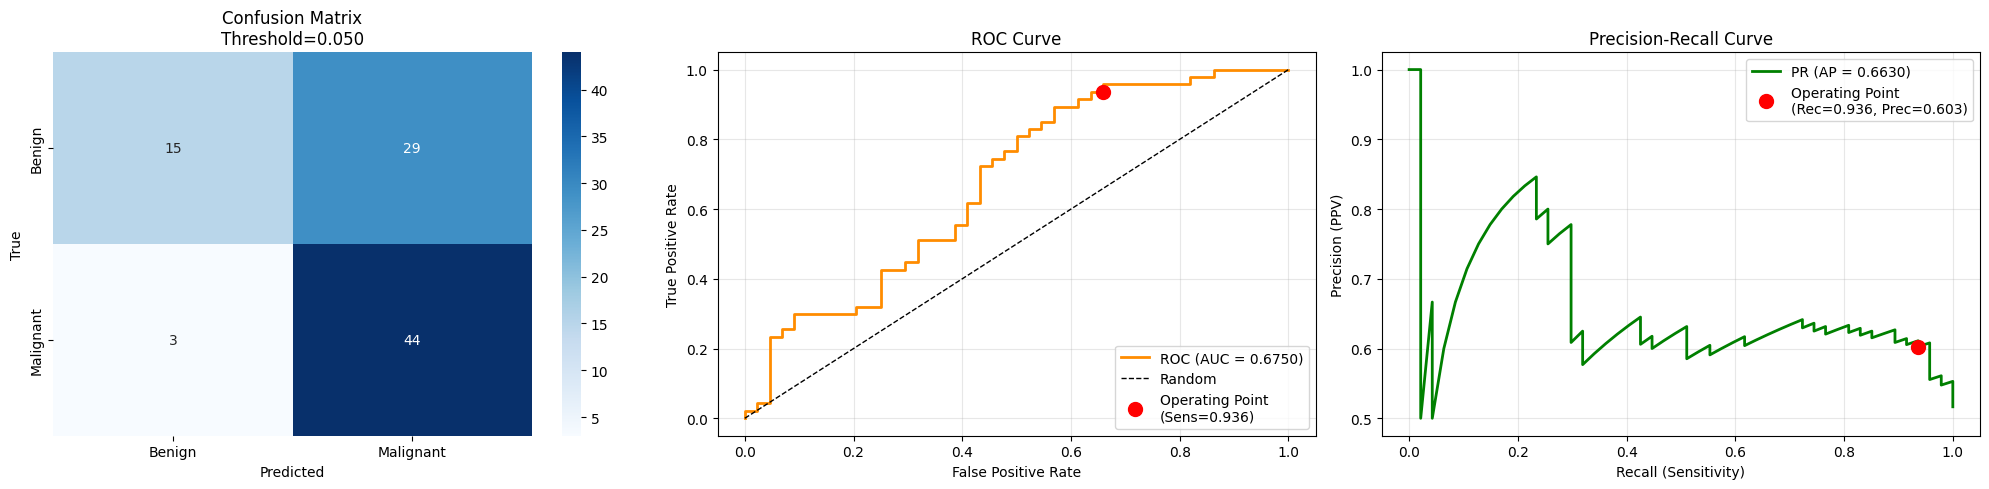

In [58]:
# Ensemble: average test probabilities across folds
base_ensemble_probs = np.mean(np.stack(base_fold_test_probs), axis=0)

print(f"\nEnsemble of {K_FOLDS} folds — evaluating on held-out test set...")

base_results = binary_model_evaluation(
    test_labels, base_ensemble_probs, CLASS_NAMES,
    title="DINOv2-Base (ViT-B/14) Linear Probe — Ensemble Test",
    threshold=None,
    min_sensitivity=MIN_SENSITIVITY_TARGET
)

## 13. 5-Fold CV — DINOv2-Small

In [59]:
print(f"\n{'='*70}")
print(f"  DINOv2-SMALL — {K_FOLDS}-Fold Cross-Validation")
print(f"{'='*70}")

skf = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=SEED)

small_fold_val_metrics = []
small_fold_test_probs = []

for fold, (train_inst_idx, val_inst_idx) in enumerate(skf.split(trainval_manifest, trainval_manifest["binary_label"])):
    print(f"\n--- Fold {fold+1}/{K_FOLDS} ---")

    # Map instance indices to sample (image) indices
    train_samp_idx = [i for inst in train_inst_idx for i in instance_to_samples[inst]]
    val_samp_idx = [i for inst in val_inst_idx for i in instance_to_samples[inst]]

    fold_train_feats = small_tv_feats[train_samp_idx]
    fold_train_labels = tv_labels[train_samp_idx]
    fold_val_feats = small_tv_feats[val_samp_idx]
    fold_val_labels = tv_labels[val_samp_idx]

    print(f"  Train: {len(train_samp_idx)} samples | Val: {len(val_samp_idx)} samples")

    # StandardScaler
    scaler = StandardScaler()
    fold_train_scaled = scaler.fit_transform(fold_train_feats)
    fold_val_scaled = scaler.transform(fold_val_feats)
    fold_test_scaled = scaler.transform(small_test_feats)

    # Logistic Regression
    lr = LogisticRegression(
        max_iter=LR_MAX_ITER, C=LR_C, class_weight=LR_CLASS_WEIGHT,
        random_state=SEED, solver='lbfgs', verbose=0
    )
    lr.fit(fold_train_scaled, fold_train_labels)

    # Val metrics at optimal threshold
    val_probs = lr.predict_proba(fold_val_scaled)[:, 1]
    val_auc = roc_auc_score(fold_val_labels, val_probs)
    opt_thresh, opt_sens, opt_spec = find_optimal_threshold(fold_val_labels, val_probs, MIN_SENSITIVITY_TARGET)
    val_pred = (val_probs >= opt_thresh).astype(int)
    tn, fp, fn, tp = confusion_matrix(fold_val_labels, val_pred).ravel()
    val_sens = tp / (tp + fn) if (tp + fn) > 0 else 0
    val_spec = tn / (tn + fp) if (tn + fp) > 0 else 0
    val_acc = np.mean(fold_val_labels == val_pred)
    val_f2 = fbeta_score(fold_val_labels, val_pred, beta=2, average='binary', zero_division=0)

    small_fold_val_metrics.append({
        'fold': fold + 1, 'threshold': opt_thresh, 'auc_roc': val_auc,
        'sensitivity': val_sens, 'specificity': val_spec, 'accuracy': val_acc, 'f2': val_f2
    })

    # Test predictions
    test_probs = lr.predict_proba(fold_test_scaled)[:, 1]
    small_fold_test_probs.append(test_probs)

    print(f"  Opt Thresh={opt_thresh:.3f} | Val AUC={val_auc:.4f} | Sens={val_sens:.4f} | Spec={val_spec:.4f} | Acc={val_acc:.4f} | F2={val_f2:.4f}")

# Fold summary
fold_df = pd.DataFrame(small_fold_val_metrics)
print(f"\n{'='*70}")
print("SMALL — Per-Fold Validation Results (at optimal threshold):")
print(fold_df.to_string(index=False, float_format=lambda x: f'{x:.4f}'))
print(f"\nMean \u00b1 Std:")
for col in ['auc_roc', 'sensitivity', 'specificity', 'accuracy', 'f2']:
    vals = fold_df[col]
    print(f"  {col}: {vals.mean():.4f} \u00b1 {vals.std():.4f}")


  DINOv2-SMALL — 5-Fold Cross-Validation

--- Fold 1/5 ---
  Train: 658 samples | Val: 164 samples
  Opt Thresh=0.050 | Val AUC=0.6768 | Sens=0.8333 | Spec=0.4125 | Acc=0.6280 | F2=0.7726

--- Fold 2/5 ---
  Train: 658 samples | Val: 164 samples
  Opt Thresh=0.050 | Val AUC=0.7260 | Sens=0.8941 | Spec=0.3418 | Acc=0.6280 | F2=0.8120

--- Fold 3/5 ---
  Train: 657 samples | Val: 165 samples
  Opt Thresh=0.050 | Val AUC=0.7638 | Sens=0.8941 | Spec=0.4875 | Acc=0.6970 | F2=0.8315

--- Fold 4/5 ---
  Train: 657 samples | Val: 165 samples
  Opt Thresh=0.050 | Val AUC=0.6604 | Sens=0.8372 | Spec=0.3418 | Acc=0.6000 | F2=0.7692

--- Fold 5/5 ---
  Train: 658 samples | Val: 164 samples
  Opt Thresh=0.050 | Val AUC=0.6874 | Sens=0.8471 | Spec=0.4304 | Acc=0.6463 | F2=0.7877

SMALL — Per-Fold Validation Results (at optimal threshold):
 fold  threshold  auc_roc  sensitivity  specificity  accuracy     f2
    1     0.0500   0.6768       0.8333       0.4125    0.6280 0.7726
    2     0.0500   0.726

## 14. Small — Ensemble Test Evaluation


Ensemble of 5 folds — evaluating on held-out test set...

🎯 Optimal threshold for ≥95% sensitivity: 0.050
   At this threshold: Sensitivity=0.9574, Specificity=0.2500

  DINOv2-Small (ViT-S/14) Linear Probe — Ensemble Test
  Classification Threshold: 0.050

  SENSITIVITY METRICS (Malignant Detection):
    Sensitivity (Recall):  0.9574 ✓
    PPV (Precision):       0.5769
    F2 Score:              0.8459

  OVERALL METRICS:
    Accuracy:              0.6154
    Specificity:           0.2500
    NPV:                   0.8462
    F1 Score:              0.7200
    AUC-ROC:               0.7021
    AUC-PR:                0.6922

  Confusion Matrix:
    TN=11   FP=33  
    FN=2    TP=45  

              precision    recall  f1-score   support

      Benign       0.85      0.25      0.39        44
   Malignant       0.58      0.96      0.72        47

    accuracy                           0.62        91
   macro avg       0.71      0.60      0.55        91
weighted avg       0.71      0.62 

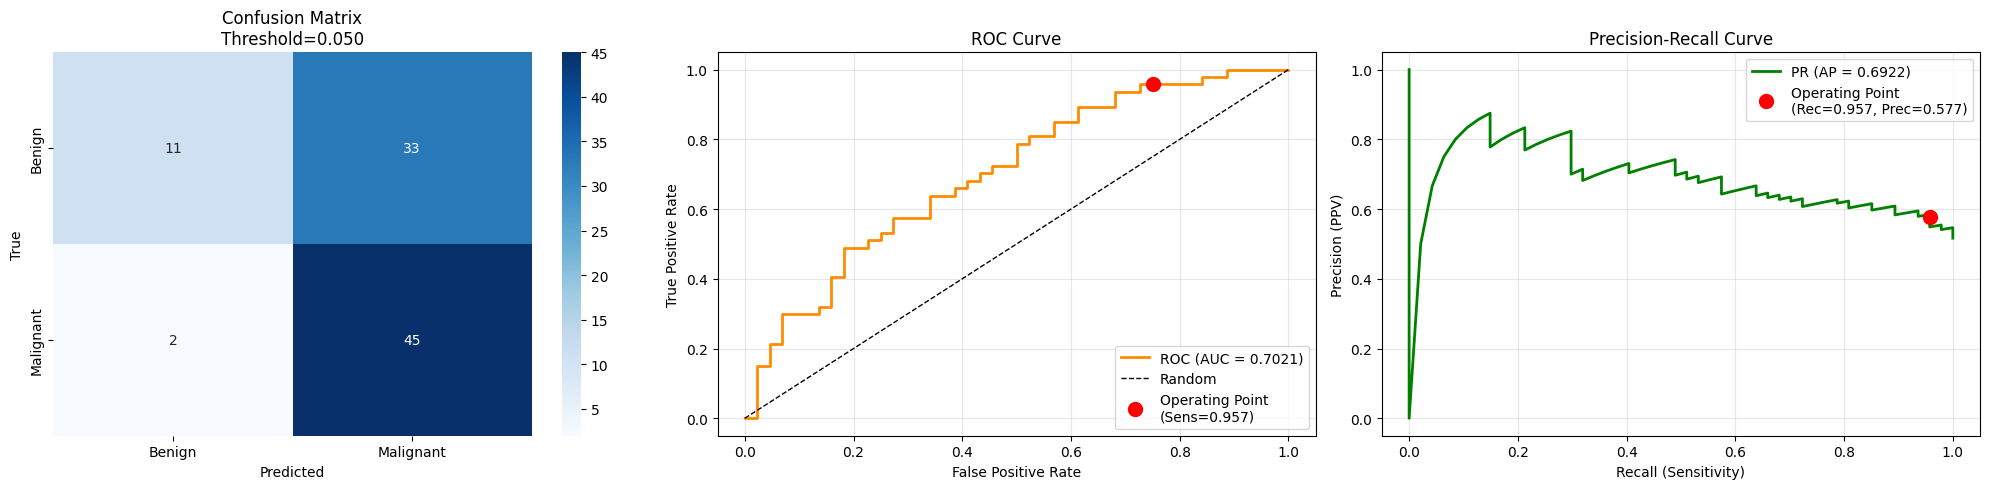

In [60]:
# Ensemble: average test probabilities across folds
small_ensemble_probs = np.mean(np.stack(small_fold_test_probs), axis=0)

print(f"\nEnsemble of {K_FOLDS} folds — evaluating on held-out test set...")

small_results = binary_model_evaluation(
    test_labels, small_ensemble_probs, CLASS_NAMES,
    title="DINOv2-Small (ViT-S/14) Linear Probe — Ensemble Test",
    threshold=None,
    min_sensitivity=MIN_SENSITIVITY_TARGET
)

## 15. Comparison: Base vs Small

In [61]:
print("\n" + "="*80)
print("LINEAR PROBE COMPARISON: DINOv2-Base vs DINOv2-Small")
print("="*80)

comparison_df = pd.DataFrame({
    'Metric': ['AUC-ROC', 'AUC-PR', 'Sensitivity', 'Specificity', 'Accuracy', 'F1', 'F2', 'PPV', 'NPV'],
    'Base (ViT-B/14)': [
        base_results['auc_roc'], base_results['auc_pr'],
        base_results['sensitivity'], base_results['specificity'],
        base_results['accuracy'], base_results['f1'], base_results['f2'],
        base_results['ppv'], base_results['npv'],
    ],
    'Small (ViT-S/14)': [
        small_results['auc_roc'], small_results['auc_pr'],
        small_results['sensitivity'], small_results['specificity'],
        small_results['accuracy'], small_results['f1'], small_results['f2'],
        small_results['ppv'], small_results['npv'],
    ],
})

comparison_df['Diff (B-S)'] = comparison_df['Base (ViT-B/14)'] - comparison_df['Small (ViT-S/14)']

print("\n" + comparison_df.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

models = {
    'Base (ViT-B/14)': base_results,
    'Small (ViT-S/14)': small_results,
}
best_model = max(models, key=lambda k: models[k]['auc_roc'])
best_auc = models[best_model]['auc_roc']

print(f"\n\nKey Findings:")
print(f"  \u2022 Best AUC-ROC: {best_model} ({best_auc:.4f})")
for name, res in models.items():
    sens_flag = '\u2713' if res['sensitivity'] >= MIN_SENSITIVITY_TARGET else '\u2717'
    print(f"  \u2022 {name}: AUC-ROC={res['auc_roc']:.4f}, Sensitivity={res['sensitivity']:.4f} {sens_flag}")

print(f"\n  \u2022 Base embed dim:  {embed_dim_base}  (86M backbone params)")
print(f"  \u2022 Small embed dim: {embed_dim_small}  (22M backbone params)")
print(f"  \u2022 All models used identical splits, transforms, and LogReg config")
print(f"  \u2022 Ensemble of {K_FOLDS} folds per model")

print("\n" + "="*80)


LINEAR PROBE COMPARISON: DINOv2-Base vs DINOv2-Small

     Metric  Base (ViT-B/14)  Small (ViT-S/14)  Diff (B-S)
    AUC-ROC           0.6750            0.7021     -0.0271
     AUC-PR           0.6630            0.6922     -0.0292
Sensitivity           0.9362            0.9574     -0.0213
Specificity           0.3409            0.2500      0.0909
   Accuracy           0.6484            0.6154      0.0330
         F1           0.7333            0.7200      0.0133
         F2           0.8429            0.8459     -0.0030
        PPV           0.6027            0.5769      0.0258
        NPV           0.8333            0.8462     -0.0128


Key Findings:
  • Best AUC-ROC: Small (ViT-S/14) (0.7021)
  • Base (ViT-B/14): AUC-ROC=0.6750, Sensitivity=0.9362 ✗
  • Small (ViT-S/14): AUC-ROC=0.7021, Sensitivity=0.9574 ✓

  • Base embed dim:  768  (86M backbone params)
  • Small embed dim: 384  (22M backbone params)
  • All models used identical splits, transforms, and LogReg config
  • Ensemble 

## 16. Visualize Comparison

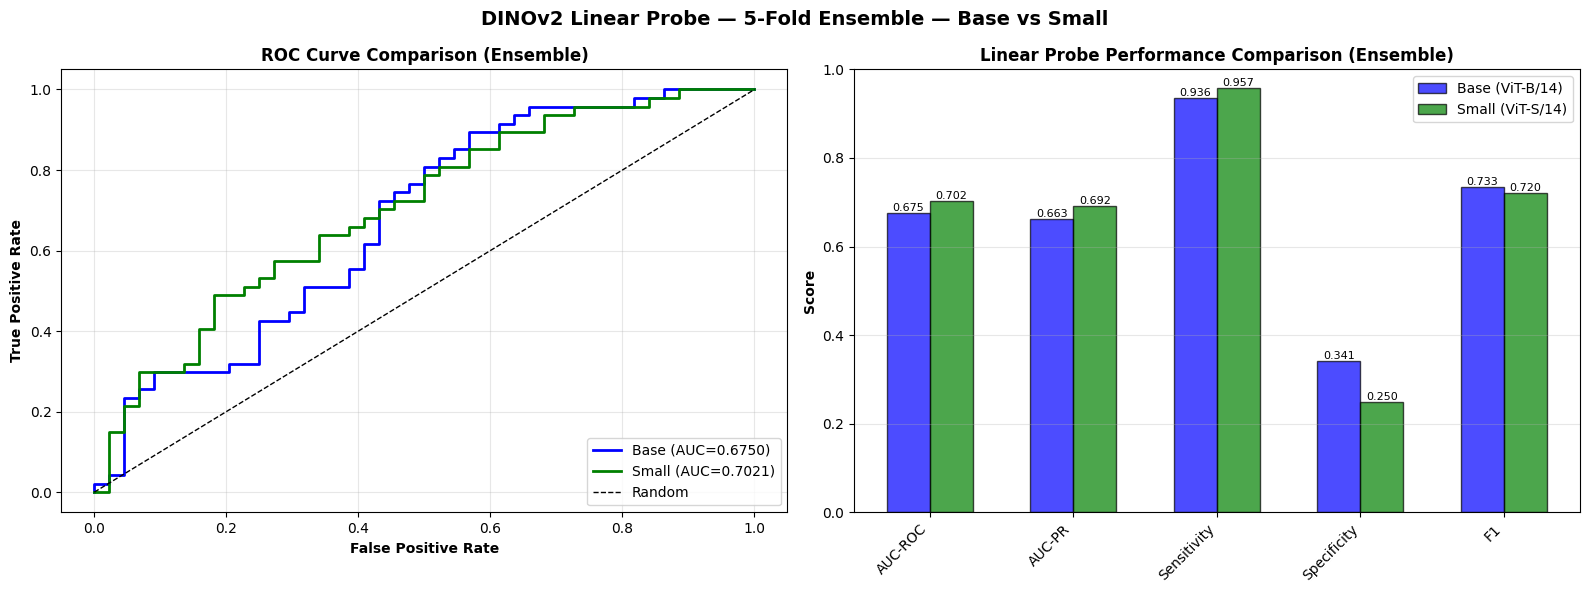

In [62]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ROC comparison
fpr_base, tpr_base, _ = roc_curve(test_labels, base_ensemble_probs)
fpr_small, tpr_small, _ = roc_curve(test_labels, small_ensemble_probs)

axes[0].plot(fpr_base, tpr_base, lw=2, color='blue',
            label=f'Base (AUC={base_results["auc_roc"]:.4f})')
axes[0].plot(fpr_small, tpr_small, lw=2, color='green',
            label=f'Small (AUC={small_results["auc_roc"]:.4f})')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
axes[0].set_xlabel('False Positive Rate', fontweight='bold')
axes[0].set_ylabel('True Positive Rate', fontweight='bold')
axes[0].set_title('ROC Curve Comparison (Ensemble)', fontweight='bold', fontsize=12)
axes[0].legend(loc='lower right')
axes[0].grid(alpha=0.3)

# Metrics bar chart
metrics = ['AUC-ROC', 'AUC-PR', 'Sensitivity', 'Specificity', 'F1']
base_vals = [base_results['auc_roc'], base_results['auc_pr'],
             base_results['sensitivity'], base_results['specificity'], base_results['f1']]
small_vals = [small_results['auc_roc'], small_results['auc_pr'],
              small_results['sensitivity'], small_results['specificity'], small_results['f1']]

x = np.arange(len(metrics))
width = 0.3

bars1 = axes[1].bar(x - width/2, base_vals, width, label='Base (ViT-B/14)',
                    color='blue', alpha=0.7, edgecolor='black')
bars2 = axes[1].bar(x + width/2, small_vals, width, label='Small (ViT-S/14)',
                    color='green', alpha=0.7, edgecolor='black')

axes[1].set_ylabel('Score', fontweight='bold')
axes[1].set_title('Linear Probe Performance Comparison (Ensemble)', fontweight='bold', fontsize=12)
axes[1].set_xticks(x)
axes[1].set_xticklabels(metrics, rotation=45, ha='right')
axes[1].legend()
axes[1].grid(alpha=0.3, axis='y')
axes[1].set_ylim([0, 1])

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        axes[1].text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.3f}', ha='center', va='bottom', fontsize=8)

plt.suptitle(f'DINOv2 Linear Probe — {K_FOLDS}-Fold Ensemble — Base vs Small',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 17. Results Summary

In [63]:
summary_df = pd.DataFrame([
    {'Model': 'Base (ViT-B/14)', **base_results},
    {'Model': 'Small (ViT-S/14)', **small_results},
])

print("\n" + "="*80)
print("FINAL RESULTS SUMMARY")
print("="*80)
print(summary_df.to_string(index=False, float_format=lambda x: f'{x:.4f}' if isinstance(x, float) else str(x)))

print(f"\n\n\u2713 Linear probe baseline established ({K_FOLDS}-fold ensemble)")
print(f"\nNext steps:")
print(f"  1. Compare these linear probe results with fine-tuned models")
print(f"  2. Compare with true zero-shot (nearest-centroid) baseline")
print(f"  3. Calculate improvement from fine-tuning: (fine-tuned_AUC - probe_AUC)")
print(f"  4. If fine-tuning improves significantly \u2192 domain adaptation is critical")
print(f"  5. If linear probe is competitive \u2192 DINOv2 features already work well")

print(f"\n{'='*80}")
print("EXPERIMENT COMPLETE")
print(f"{'='*80}")


FINAL RESULTS SUMMARY
           Model  threshold  accuracy  precision  recall  sensitivity  specificity    ppv    npv     f1     f2  auc_roc  auc_pr  tp  tn  fp  fn
 Base (ViT-B/14)     0.0500    0.6484     0.6027  0.9362       0.9362       0.3409 0.6027 0.8333 0.7333 0.8429   0.6750  0.6630  44  15  29   3
Small (ViT-S/14)     0.0500    0.6154     0.5769  0.9574       0.9574       0.2500 0.5769 0.8462 0.7200 0.8459   0.7021  0.6922  45  11  33   2


✓ Linear probe baseline established (5-fold ensemble)

Next steps:
  1. Compare these linear probe results with fine-tuned models
  2. Compare with true zero-shot (nearest-centroid) baseline
  3. Calculate improvement from fine-tuning: (fine-tuned_AUC - probe_AUC)
  4. If fine-tuning improves significantly → domain adaptation is critical
  5. If linear probe is competitive → DINOv2 features already work well

EXPERIMENT COMPLETE
